<a href="https://colab.research.google.com/github/Gabriel-Roledo-ds/German_Credit-Scorecard_e_Politica_de_Credito/blob/main/German_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# German Credit — Análise de Risco e Política de Crédito

## Índice (CRISP-DM)
###1 - Business Understanding
###2 - Data Understanding
###3 - Data Preparation
###4 - Modeling
###5 - Evaluation
###6 - Deployment

#1 - Business Understanding

**Problema de negócio:** o dataset German Credit foi compilado pelo Prof. Hans Hofmann (Institut für Statistik und Ökonometrie, Universität Hamburg) e reúne 1.000 clientes de crédito com 20 variáveis (7 numéricas, 13 categóricas). A documentação não identifica uma instituição financeira específica por trás dos dados; é um dataset acadêmico usado como benchmark de risco de crédito, mas o cenário de negócio permanece válido como exercício: **uma instituição que concede crédito ao consumidor quer reduzir a inadimplência da carteira sem comprometer o volume de aprovações.**

**Hipótese de trabalho:** existem variáveis do cadastro do cliente (situação financeira, histórico de crédito, moradia) que discriminam bem entre bom e mau pagador, e essas variáveis podem virar regras de decisão.

**Métrica de sucesso:** a própria documentação do dataset (seção 8) define uma matriz de custo assimétrica obrigatória para avaliar qualquer modelo construído sobre esses dados — **aprovar um mau pagador (classificar bad como good) custa 5x mais do que reprovar um bom pagador (classificar good como bad)**. Por isso, a métrica de sucesso central deste projeto não é apenas reduzir a taxa de inadimplência entre aprovados abaixo dos 30% da carteira atual, mas reduzir o **custo esperado da carteira** frente ao cenário de aprovar todos os clientes, respeitando essa assimetria 5:1 — sem rejeitar volume excessivo de bons pagadores.

#2 - Data Understanding

Objetivo: entender a estrutura da base e identificar quais variáveis mais separam bons e maus pagadores.

### Setup

Setup do ambiente: bibliotecas de manipulação de dados (pandas, numpy), visualização (matplotlib, seaborn) e modelagem (scikit-learn)..

In [2]:
# Setup do projeto: bibliotecas e configurações padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Setup OK')

Setup OK


In [3]:
# Monta o Google Drive no ambiente do Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Carrega a base direto do Drive
# Ajuste o caminho conforme a pasta onde o CSV esta salvo
caminho = '/content/drive/MyDrive/Dados_Estudo/raw/german_credit/german_credit_data.csv'

df = pd.read_csv(caminho)

print(df.shape)
df.head()

(1000, 21)


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,4,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,2,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,3,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,4,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,4,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


### Carregamento da base

1.000 clientes e 21 colunas (20 variáveis + target), confirmando o que a documentação do dataset descreve.

In [5]:
# Tipos de dado e valores nao nulos por coluna
# Criar variável para metadados
# (nomes das colunas, tipos, quantidade de nulos, percentual de nulos, cardinalidade)

def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata = metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)

    return metadata

In [6]:
generate_metadata(df)

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,residence_since,int64,0,0.0,4
1,month_duration,int64,0,0.0,33
2,n_guarantors,int64,0,0.0,2
3,credit_amount,int64,0,0.0,921
4,n_credits,int64,0,0.0,4
5,payment_to_income_ratio,int64,0,0.0,4
6,age,int64,0,0.0,53
7,telephone,object,0,0.0,2
8,job,object,0,0.0,4
9,housing,object,0,0.0,3


Nenhum valor nulo em nenhuma das 21 colunas — base limpa, sem tratamento de nulo necessário nesta etapa. 7 variáveis numéricas e 14 categóricas.

In [7]:
df.describe().round(2)

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


In [13]:
colunas = ['payment_to_income_ratio', 'n_guarantors', 'residence_since', 'n_credits']

for col in colunas:
    contagem = df[col].value_counts().sort_index()
    percentual = df[col].value_counts(normalize=True).sort_index() * 100
    print(f'--- {col} ---')
    print(pd.DataFrame({'qtd': contagem, 'pct': percentual.round(2)}))
    print()

--- payment_to_income_ratio ---
                         qtd   pct
payment_to_income_ratio           
1                        136  13.6
2                        231  23.1
3                        157  15.7
4                        476  47.6

--- n_guarantors ---
              qtd   pct
n_guarantors           
1             845  84.5
2             155  15.5

--- residence_since ---
                 qtd   pct
residence_since           
1                130  13.0
2                308  30.8
3                149  14.9
4                413  41.3

--- n_credits ---
           qtd   pct
n_credits           
1          633  63.3
2          333  33.3
3           28   2.8
4            6   0.6



In [14]:
df.describe(include='object')

,status_account,credit_history,purpose,status_savings,years_employment,status_and_sex,secondary_obligor,collateral,other_installment_plans,housing,job,telephone,is_foreign_worker,target
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,3,4,3,3,4,2,2,2
top,no checking account,existing credits paid back duly till now,radio/television,< 100 DM,1 to < 4 years,male : single,none,real estate,none,own,skilled employee/ official,none,yes,good
freq,394,530,280,603,339,548,907,332,814,713,630,596,963,700


In [18]:
# Lista das categóricas (exclui o target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'target']

# Target binário: 1 = bad (evento), 0 = good
df['target_bin'] = (df['target'] == 'bad').astype(int)

for col in cat_cols:
    taxa = df.groupby(col)['target_bin'].agg(['count', 'mean'])
    taxa['mean'] = (taxa['mean'] * 100).round(2)
    taxa.columns = ['qtd', 'pct_bad']
    print(f'--- {col} ---')
    print(taxa.sort_values('pct_bad', ascending=False))
    print()

--- status_account ---
                     qtd  pct_bad
status_account                   
< 0 DM               274    49.27
0 to < 200 DM        269    39.03
>= 200 DM             63    22.22
no checking account  394    11.68

--- credit_history ---
                                                    qtd  pct_bad
credit_history                                                  
no credits taken/ all credits paid back duly         40    62.50
all credits at this bank paid back duly              49    57.14
existing credits paid back duly till now            530    31.89
delay in paying off in the past                      88    31.82
critical account/ other credits existing (not a...  293    17.06

--- purpose ---
                     qtd  pct_bad
purpose                          
education             50    44.00
others                12    41.67
car (new)            234    38.03
repairs               22    36.36
business              97    35.05
domestic appliances   12    33.33
furni

In [22]:
disc_cols = ['payment_to_income_ratio', 'residence_since', 'n_credits', 'n_guarantors']

for col in disc_cols:
    taxa = df.groupby(col)['target_bin'].agg(['count', 'mean'])
    taxa['mean'] = (taxa['mean'] * 100).round(2)
    taxa.columns = ['qtd', 'pct_bad']
    print(f'--- {col} ---')
    print(taxa)
    print()

--- payment_to_income_ratio ---
                         qtd  pct_bad
payment_to_income_ratio              
1                        136    25.00
2                        231    26.84
3                        157    28.66
4                        476    33.40

--- residence_since ---
                 qtd  pct_bad
residence_since              
1                130    27.69
2                308    31.49
3                149    28.86
4                413    30.02

--- n_credits ---
           qtd  pct_bad
n_credits              
1          633    31.60
2          333    27.63
3           28    21.43
4            6    33.33

--- n_guarantors ---
              qtd  pct_bad
n_guarantors              
1             845    30.06
2             155    29.68



In [23]:
for col in ['credit_amount', 'month_duration', 'age']:
    faixas = pd.qcut(df[col], q=5, duplicates='drop')
    taxa = df.groupby(faixas, observed=True)['target_bin'].agg(['count', 'mean'])
    taxa['mean'] = (taxa['mean'] * 100).round(2)
    taxa.columns = ['qtd', 'pct_bad']
    print(f'--- {col} ---')
    print(taxa)
    print()

--- credit_amount ---
                   qtd  pct_bad
credit_amount                  
(249.999, 1262.0]  201    30.35
(1262.0, 1906.8]   199    24.12
(1906.8, 2852.4]   200    27.00
(2852.4, 4720.0]   200    26.00
(4720.0, 18424.0]  200    42.50

--- month_duration ---
                qtd  pct_bad
month_duration              
(3.999, 12.0]   359    21.17
(12.0, 15.0]     72    18.06
(15.0, 24.0]    339    32.15
(24.0, 30.0]     57    33.33
(30.0, 72.0]    173    47.98

--- age ---
                qtd  pct_bad
age                         
(18.999, 26.0]  240    39.17
(26.0, 30.0]    171    31.58
(30.0, 36.0]    216    25.93
(36.0, 45.0]    187    26.20
(45.0, 75.0]    186    25.27



In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
for col in df.select_dtypes(include='number').columns.drop('target_bin'):
    print(f'{col}: zeros={(df[col] == 0).sum()}, negativos={(df[col] < 0).sum()}')

month_duration: zeros=0, negativos=0
credit_amount: zeros=0, negativos=0
payment_to_income_ratio: zeros=0, negativos=0
residence_since: zeros=0, negativos=0
age: zeros=0, negativos=0
n_credits: zeros=0, negativos=0
n_guarantors: zeros=0, negativos=0


In [20]:
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).index.tolist())
    print()

--- status_account ---
['no checking account', '< 0 DM', '0 to < 200 DM', '>= 200 DM']

--- credit_history ---
['existing credits paid back duly till now', 'critical account/ other credits existing (not at this bank)', 'delay in paying off in the past', 'all credits at this bank paid back duly', 'no credits taken/ all credits paid back duly']

--- purpose ---
['radio/television', 'car (new)', 'furniture/equipment', 'car (used)', 'business', 'education', 'repairs', 'domestic appliances', 'others', 'retraining']

--- status_savings ---
['< 100 DM', 'unknown/ no savings account', '100 to < 500 DM', '500 to < 1000 DM', '>= 1000 DM']

--- years_employment ---
['1 to < 4 years', '>= 7 years', '4 to < 7 years', '< 1 year', 'unemployed']

--- status_and_sex ---
['male : single', 'female : divorced/separated/married', 'male : married/widowed', 'male : divorced/separated']

--- secondary_obligor ---
['none', 'guarantor', 'co-applicant']

--- collateral ---
['real estate', 'none', 'car', 'savings

In [ ]:
# Proporcao de bons x maus pagadores
tx_inadimplencia_geral = (df['target'] == 'bad').mean()
print(f'Taxa de inadimplencia geral: {tx_inadimplencia_geral:.1%}')

df['target'].value_counts(normalize=True)

Taxa de inadimplencia geral: 30.0%


,proportion
target,
good,0.7
bad,0.3


## Descrição do dataset

Base com 1000 clientes que solicitaram crédito, com 21 colunas: 7 numéricas, 13 categóricas e 1 target. Os valores monetários estão em marcos alemães (DM), o que indica que é o German Credit Dataset (UCI, 1994). O objetivo é prever a inadimplência para construir um scorecard tradicional e uma política de crédito, e comparar com uma regressão logística.

## Qualidade e estrutura

- Base limpa: 0 nulos, 0 duplicadas, nenhum valor escondido nas categóricas ('?', 'N/A', espaços ou inconsistências de escrita) e nenhum zero ou valor negativo nas numéricas.
- Não há ID do cliente nem data de contratação. Isso impede análise temporal e validação out-of-time (OOT), o que é uma limitação do estudo.
- `unknown/ no savings account` em `status_savings` e `none` em `secondary_obligor`, `collateral`, `other_installment_plans` e `telephone` são níveis válidos, não nulos. Foram mantidos como categorias próprias (por exemplo, `unknown/ no savings account` tem 17,5% de bad, ou seja, carrega informação).

## Target

- `target` tem as classes `good` (700, 70%) e `bad` (300, 30%). Foi criada a coluna `target_bin` (1 = bad, evento de interesse).
- Desbalanceamento moderado. Será usado split estratificado e, como são só 300 eventos, validação cruzada em vez de um único split.

## Numéricas

- `credit_amount` (921 valores distintos) e `month_duration` (33): média acima da mediana e valores altos legítimos (até 18.424 DM e 72 meses), indicando assimetria à direita. Não serão removidos.
- `age` (53 valores): 19 a 75 anos, mediana 33. Candidata a faixas no scorecard.
- `payment_to_income_ratio`, `residence_since`, `n_credits` e `n_guarantors`: cardinalidade de 2 a 4, tratadas como ordinais/categóricas. Em `n_credits`, as categorias 3 e 4 somam só 34 casos e serão agrupadas em "3+".

### Taxa de inadimplência nas numéricas

As contínuas foram divididas em 5 faixas por quantis para avaliar a taxa de bad.

| Variável | Menor % bad | Maior % bad | Amplitude | Comportamento |
|---|---|---|---|---|
| `month_duration` | 18,1% (12 a 15 meses) | 48,0% (> 30 meses) | ~30 p.p. | Sobe com o prazo; leve não monotonicidade na faixa de 12 a 15 meses |
| `credit_amount` | 24,1% (1.262 a 1.907 DM) | 42,5% (> 4.720 DM) | ~18 p.p. | Não linear: o risco só se destaca na faixa mais alta |
| `age` | 25,3% (> 45 anos) | 39,2% (até 26 anos) | ~14 p.p. | Cai até os 30 anos e estabiliza depois |
| `payment_to_income_ratio` | 25,0% (faixa 1) | 33,4% (faixa 4) | ~8 p.p. | Monotônica crescente, mas de baixa amplitude |
| `residence_since` | 27,7% (faixa 1) | 31,5% (faixa 2) | ~4 p.p. | Sem tendência |
| `n_guarantors` | 29,7% (2) | 30,1% (1) | ~0,4 p.p. | Não discrimina |
| `n_credits` | 21,4% (3) | 33,3% (4, só 6 casos) | ~12 p.p. | Leve queda com mais créditos; extremo é ruído |

- `month_duration` é a numérica mais informativa: o bad passa de 21% (até 12 meses) para 48% (acima de 30 meses), mais que o dobro.
- Em `credit_amount`, as quatro primeiras faixas ficam entre 24% e 30%, sem tendência clara. Há indício de que agrupá-las e separar a faixa mais alta seja suficiente. Como `credit_amount` e `month_duration` provavelmente são correlacionadas, parte do efeito pode ser a mesma informação (a conferir pela correlação de Pearson).
- Em `age`, a diferença se concentra nos clientes mais jovens (39,2% até 26 anos, contra cerca de 26% a partir dos 30). Duas ou três faixas devem bastar.
- Em `n_credits`, agrupar 3 e 4 em "3+" (34 casos) resulta em cerca de 23,5% de bad. A categoria 4 isolada tem 6 casos (2 inadimplentes), portanto é ruído.

## Variáveis categóricas mais discriminantes (maior variação de % bad)

| Variável | Menor % bad | Maior % bad | Amplitude |
|---|---|---|---|
| credit_history | 17,1% (conta crítica) | 62,5% (sem créditos) | ~45 p.p. |
| status_account | 11,7% (sem conta) | 49,3% (< 0 DM) | ~38 p.p. |
| purpose | 11,1% (retraining) | 44,0% (education) | ~33 p.p. |
| status_savings | 12,5% (>= 1000 DM) | 36,0% (< 100 DM) | ~23 p.p. |
| years_employment | 22,4% (4 a 7 anos) | 40,7% (< 1 ano) | ~18 p.p. |

São as candidatas a maior IV. A confirmação vem na etapa de WoE/IV. Atenção: em `purpose`, parte da amplitude vem de categorias com poucos casos.

## Comportamentos que contrariam a intuição

Alguns resultados da análise multivariada vão contra o que o senso comum esperaria. Eles não devem ser lidos como regras de negócio: são padrões observados na base, e cada um tem uma explicação provável que precisa ser validada com o time de negócio antes de ser tratada como conclusão.

### `credit_history` (histórico de crédito)

- **O que a base mostra:** clientes que nunca tomaram crédito ou que quitaram todos os créditos têm as piores taxas de inadimplência (62,5% e 57,1%). Já os clientes com "conta crítica / outros créditos existentes" têm a melhor taxa (17,1%).
- **Por que é contraintuitivo:** o esperado seria o contrário, com bom histórico associado a menos inadimplência e conta crítica associada a mais.
- **Explicação provável:** viés de seleção. A base parece conter apenas clientes que foram aprovados. Para liberar crédito a alguém com conta crítica, o banco provavelmente foi muito rigoroso e aprovou somente os casos que pareciam seguros. Já os clientes com histórico "limpo" passavam com mais facilidade, inclusive perfis frágeis em outros aspectos.
- **Implicação:** não interpretar como "histórico ruim reduz o risco". O resultado reflete a política de aprovação vigente. Como não há clientes recusados na base, um modelo treinado nela pode errar ao avaliar o público que a política antiga barrava. Técnicas de *reject inference* (estimar o comportamento dos recusados) podem ajudar, mas dependem de dados que a base não tem.

### `status_account` (situação da conta corrente)

- **O que a base mostra:** clientes sem conta corrente são o grupo mais seguro (11,7% de bad), contra 49,3% de quem tem saldo negativo.
- **Por que é contraintuitivo:** a ausência de conta poderia indicar menor vínculo com o banco e, portanto, maior risco.
- **Explicação provável:** possivelmente o mesmo viés de seleção, em que clientes sem histórico bancário só foram aprovados se tinham um perfil muito forte em outros aspectos. Também pode haver um tipo diferente de relacionamento com o banco. Essas são hipóteses, sem confirmação.
- **Implicação:** a variável é muito discriminante (de 12% a 49% de bad) e deve ser considerada no modelo, mesmo com a explicação ainda incerta.

### `is_foreign_worker` (trabalhador estrangeiro)

- **O que a base mostra:** estrangeiros têm 10,8% de bad, contra 30,7% dos demais.
- **Por que não é possível concluir:** são apenas 37 casos, o que corresponde a cerca de 4 inadimplentes. Com tão poucos registros, a taxa oscila bastante por acaso, então a diferença pode ser ruído.
- **Implicação:** não tirar conclusões sobre esse grupo. Além disso, usar nacionalidade como critério de decisão de crédito envolve risco regulatório e de discriminação, e o uso da variável deve ser avaliado com cuidado.

### `collateral` (garantia)

- **O que a base mostra:** clientes sem garantia têm a menor taxa de bad (21,3%), e os que oferecem poupança vinculada ou seguro de vida têm a maior (43,5%).
- **Por que é contraintuitivo:** ter garantia deveria reduzir o risco de calote, não aumentá-lo.
- **Explicação provável:** causalidade invertida. A garantia não causa a inadimplência: o banco tende a exigi-la justamente dos perfis já considerados mais arriscados, enquanto clientes tidos como seguros não precisam oferecê-la. Assim, o grupo "com garantia" já é de maior risco antes de a garantia entrar na análise.
- **Implicação:** a variável pode ser útil no modelo, mas seu sinal não deve ser interpretado como "garantia aumenta o risco".

### Resumo

| Variável | Achado | Explicação provável | Confiança |
|---|---|---|---|
| `credit_history` | Histórico "limpo" tem mais bad | Viés de seleção | Média |
| `status_account` | Sem conta é o grupo mais seguro | Possível viés de seleção | Baixa |
| `is_foreign_worker` | Estrangeiros têm menos bad | Amostra pequena (ruído) | Não concluir |
| `collateral` | Com garantia tem mais bad | Causalidade invertida | Média |

Todas as explicações acima são hipóteses. Para confirmá-las, é necessário o dicionário de dados e a validação do time de negócio (por exemplo, se a base inclui apenas clientes aprovados e como a garantia era exigida).

## Categorias raras (instáveis)

- `purpose`: retraining (9), others (12), domestic appliances (12), repairs (22).
- `job`: unemployed/unskilled - non-resident (22).
- `secondary_obligor`: co-applicant (41) e guarantor (52).
- `is_foreign_worker`: no (37).
- `n_credits`: categorias 3 (28) e 4 (6).
- Com 9 casos, 11% de bad significa 1 inadimplente: é ruído, não padrão. Serão agrupadas por taxa de bad parecida ou por afinidade antes do WoE/IV.

## Baixo poder discriminativo (candidatas a IV baixo)

- `n_guarantors` (30,1% vs 29,7%) e `residence_since` (27,7% a 31,5%, sem tendência): não apresentam diferença relevante de risco, sendo candidatas a descarte.
- `telephone` (31,4% vs 28,0%) e `job` (28% a 34,5%) variam pouco entre categorias.
- `payment_to_income_ratio` tem comportamento coerente (monotônico), mas de baixa amplitude (~8 p.p.).
- `is_foreign_worker` e `secondary_obligor` são muito concentradas (96,3% e 90,7% em uma categoria), e as minoritárias são pequenas.

## Atenção ética e regulatória

- `status_and_sex` mistura sexo e estado civil. A decisão de usá-la ou não no modelo deve ser consciente e documentada, por risco de discriminação e restrição legal.
- `age` e `is_foreign_worker` merecem a mesma análise de fairness.

## Observações para o scorecard

- Várias variáveis são ordinais naturais (`status_savings`, `years_employment`, `status_account`), o que ajuda a manter a monotonicidade do WoE.
- Categorias com % bad parecido e volume baixo serão agrupadas antes do cálculo do IV.
- Binning previsto para as contínuas: `credit_amount` (agrupar as quatro faixas inferiores e separar a mais alta), `age` (duas ou três faixas) e `month_duration` (faixas que corrijam a leve não monotonicidade entre 12 e 15 meses).


## Perguntas ao time de negócio

1. Os dados incluem apenas clientes aprovados? Existem recusados disponíveis?
2. Qual é a definição de "bad" (atraso de quantos dias)?
3. Qual é a codificação de `payment_to_income_ratio`, `residence_since` e `n_guarantors`?
4. Há data de concessão para validação temporal?

##Gráficos

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
CORES = {'good': '#4C72B0', 'bad': '#C44E52'}


def _grid(n, ncols=3, w=6, h=4):
    """Cria uma grade de eixos e esconde os que sobrarem."""
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows))
    axes = np.array(axes).flatten()
    for ax in axes[n:]:
        ax.axis('off')
    return fig, axes[:n]


def _rotulo(txt, max_len=28):
    txt = str(txt)
    return txt if len(txt) <= max_len else txt[:max_len - 1] + '…'


# 1. Univariada: numéricas contínuas (histograma + boxplot)
def plot_univariada_numericas(df, cols):
    fig, axes = plt.subplots(2, len(cols), figsize=(6 * len(cols), 8))
    axes = np.atleast_2d(axes)
    for i, col in enumerate(cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i])
        axes[0, i].axvline(df[col].mean(), color='red', ls='--', label='média')
        axes[0, i].axvline(df[col].median(), color='green', ls='--', label='mediana')
        axes[0, i].set_title(f'Distribuição de {col}')
        axes[0, i].legend()
        sns.boxplot(x=df[col], ax=axes[1, i])
        axes[1, i].set_title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()


# 2. Univariada: categóricas e discretas (barras com % e n)
def plot_univariada_categoricas(df, cols):
    fig, axes = _grid(len(cols), ncols=3, w=7, h=4)
    for ax, col in zip(axes, cols):
        vc = df[col].value_counts().sort_values()
        pct = vc / len(df) * 100
        ax.barh([_rotulo(i) for i in vc.index], vc.values, color='#4C72B0')
        for y, (n, p) in enumerate(zip(vc.values, pct.values)):
            ax.text(n, y, f' {n} ({p:.1f}%)', va='center', fontsize=8)
        ax.set_xlim(0, vc.max() * 1.3)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()


# 3. Multivariada: KDE das contínuas por target
def plot_kde_target(df, cols, target='target'):
    fig, axes = _grid(len(cols), ncols=3, w=6, h=4)
    for ax, col in zip(axes, cols):
        sns.kdeplot(data=df, x=col, hue=target, hue_order=['good', 'bad'],
                    palette=CORES, common_norm=False, fill=True, alpha=0.3,
                    cut=0, ax=ax)
        ax.set_title(f'{col} por target')
    plt.tight_layout()
    plt.show()


# 4. Multivariada: barras 100% empilhadas por target (ordenadas por % bad)
def plot_barras_100(df, cols, target='target', target_bin='target_bin'):
    fig, axes = _grid(len(cols), ncols=3, w=7, h=4)
    taxa_global = df[target_bin].mean() * 100
    for ax, col in zip(axes, cols):
        ct = pd.crosstab(df[col], df[target], normalize='index') * 100
        ct = ct[['good', 'bad']].sort_values('bad')
        n = df[col].value_counts()
        ct.index = [f'{_rotulo(i)} (n={n[i]})' for i in ct.index]
        ct.plot(kind='barh', stacked=True, ax=ax, color=[CORES['good'], CORES['bad']],
                legend=False)
        ax.axvline(100 - taxa_global, color='black', ls='--', lw=1)
        ax.set_xlim(0, 100)
        ax.set_ylabel('')
        ax.set_title(col)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    plt.show()


# 5. Correlação de Pearson
def plot_correlacao(df, cols):
    plt.figure(figsize=(9, 7))
    sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlação de Pearson')
    plt.show()


# 6. Outliers pelo IQR (tabela)
def resumo_outliers(df, cols, target_bin='target_bin'):
    linhas = []
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
        linhas.append({
            'variavel': col,
            'lim_inf': round(lim_inf, 1),
            'lim_sup': round(lim_sup, 1),
            'qtd_outliers': len(out),
            'pct_outliers': round(len(out) / len(df) * 100, 1),
            'pct_bad_outliers': round(out[target_bin].mean() * 100, 1) if len(out) else np.nan,
            'pct_bad_base': round(df[target_bin].mean() * 100, 1),
        })
    return pd.DataFrame(linhas)


# 7. Taxa de bad por faixa (contínuas) com barras + linha da taxa global
def plot_bad_por_faixa(df, cols, q=5, target_bin='target_bin'):
    fig, axes = _grid(len(cols), ncols=3, w=6, h=4)
    taxa_global = df[target_bin].mean() * 100
    for ax, col in zip(axes, cols):
        faixas = pd.qcut(df[col], q=q, duplicates='drop')
        taxa = df.groupby(faixas, observed=True)[target_bin].mean() * 100
        ax.bar(range(len(taxa)), taxa.values, color=CORES['bad'], alpha=0.8)
        ax.axhline(taxa_global, color='black', ls='--', lw=1, label='média da base')
        ax.set_xticks(range(len(taxa)))
        ax.set_xticklabels([str(i) for i in taxa.index], rotation=30, ha='right', fontsize=8)
        ax.set_ylabel('% bad')
        ax.set_title(f'% bad por faixa de {col}')
        ax.legend()
    plt.tight_layout()
    plt.show()


# Função mestra
def eda_visual(df, cont_cols, disc_cols, cat_cols, target='target', target_bin='target_bin'):
    print('=== 1. Univariada: contínuas ===')
    plot_univariada_numericas(df, cont_cols)

    print('=== 2. Univariada: categóricas e discretas ===')
    plot_univariada_categoricas(df, cat_cols + disc_cols)

    print('=== 3. KDE por target ===')
    plot_kde_target(df, cont_cols, target)

    print('=== 4. Barras 100% por target ===')
    plot_barras_100(df, cat_cols + disc_cols, target, target_bin)

    print('=== 5. % bad por faixa (contínuas) ===')
    plot_bad_por_faixa(df, cont_cols, target_bin=target_bin)

    print('=== 6. Correlação de Pearson ===')
    plot_correlacao(df, cont_cols + disc_cols + [target_bin])

    print('=== 7. Outliers (IQR) ===')
    display(resumo_outliers(df, cont_cols, target_bin))

=== 1. Univariada: contínuas ===


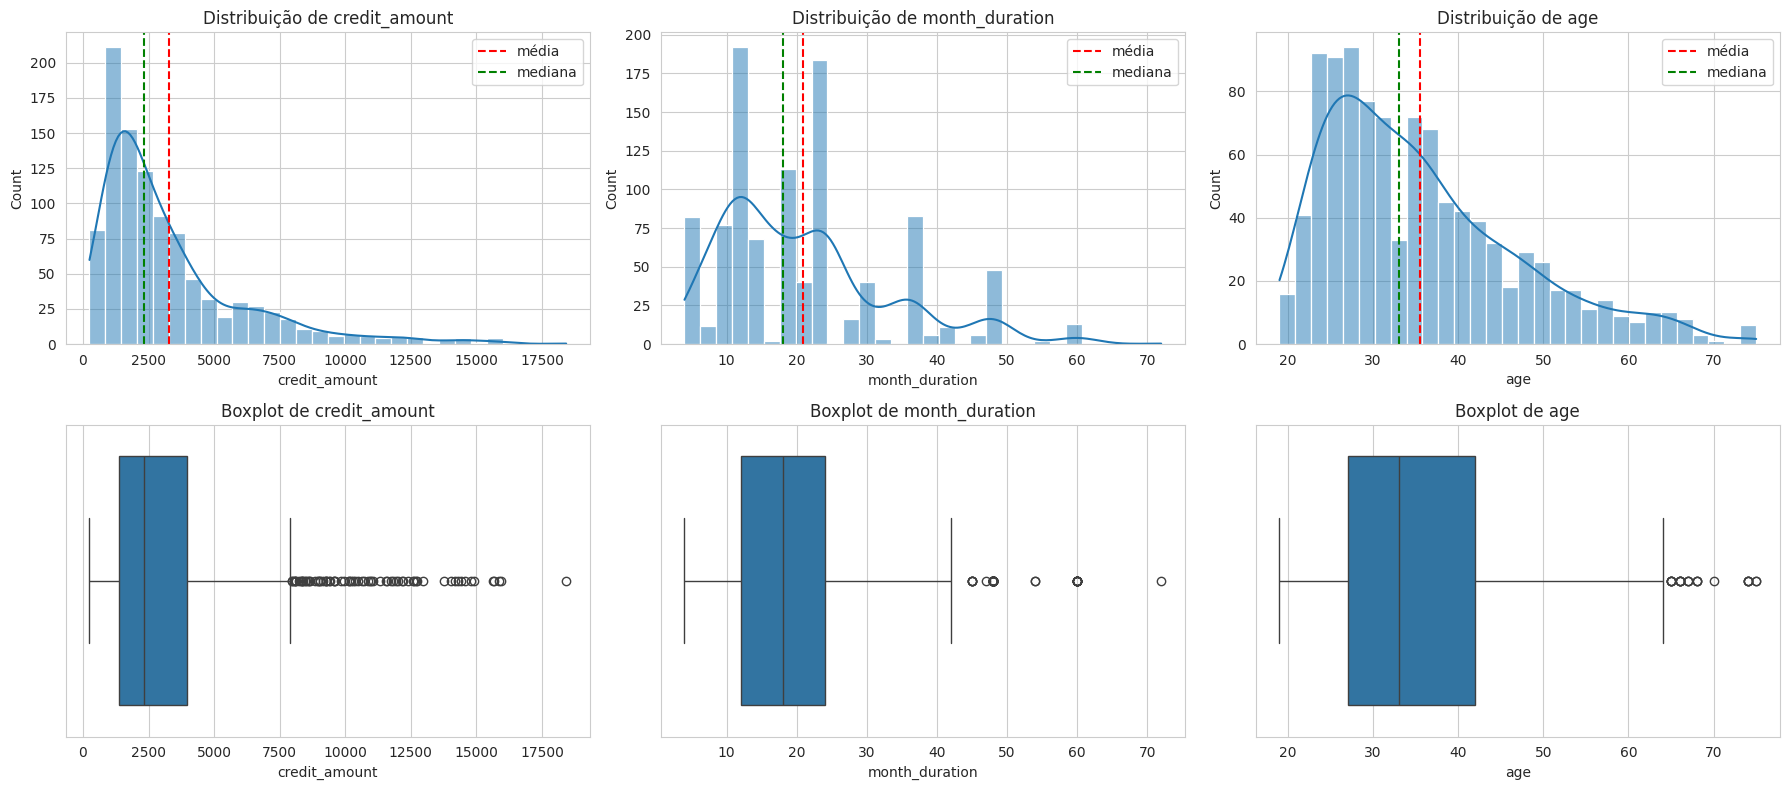

=== 2. Univariada: categóricas e discretas ===


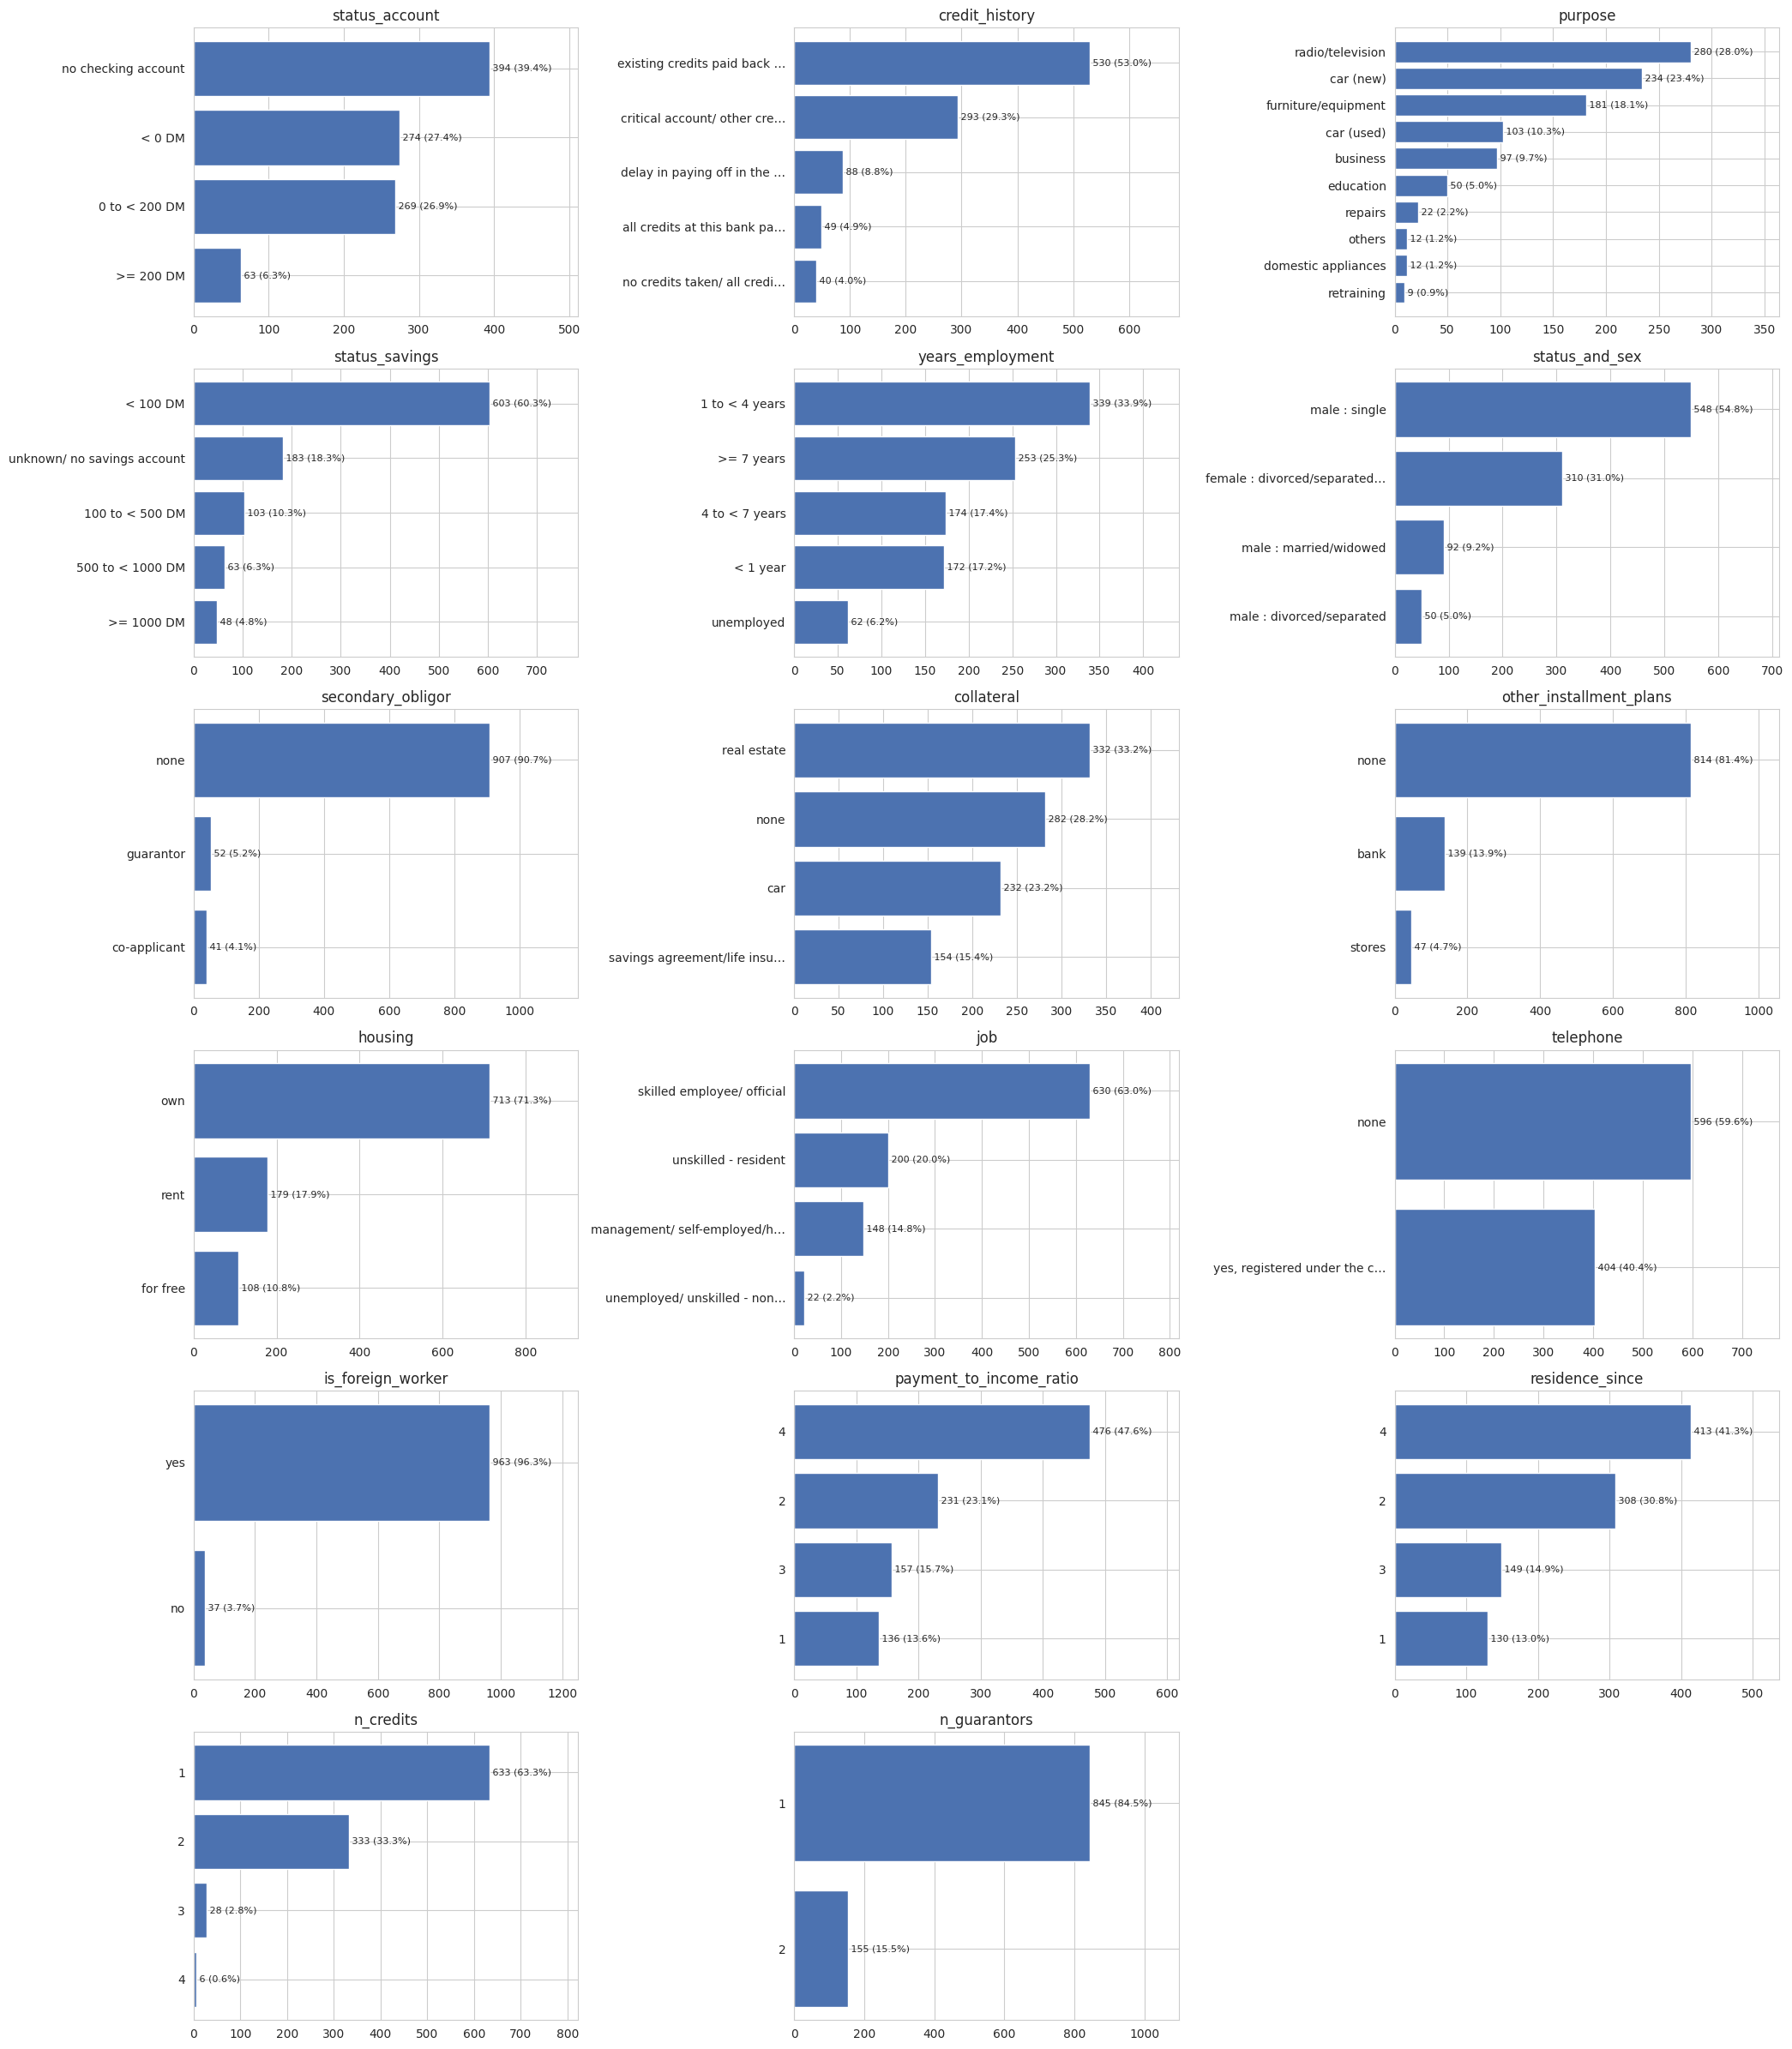

=== 3. KDE por target ===


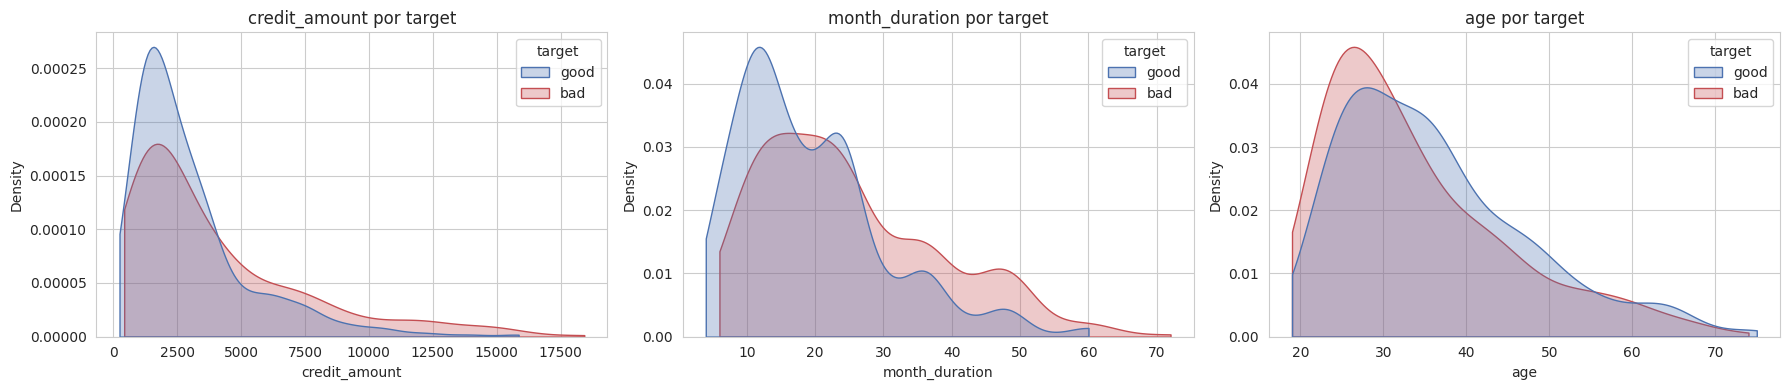

=== 4. Barras 100% por target ===


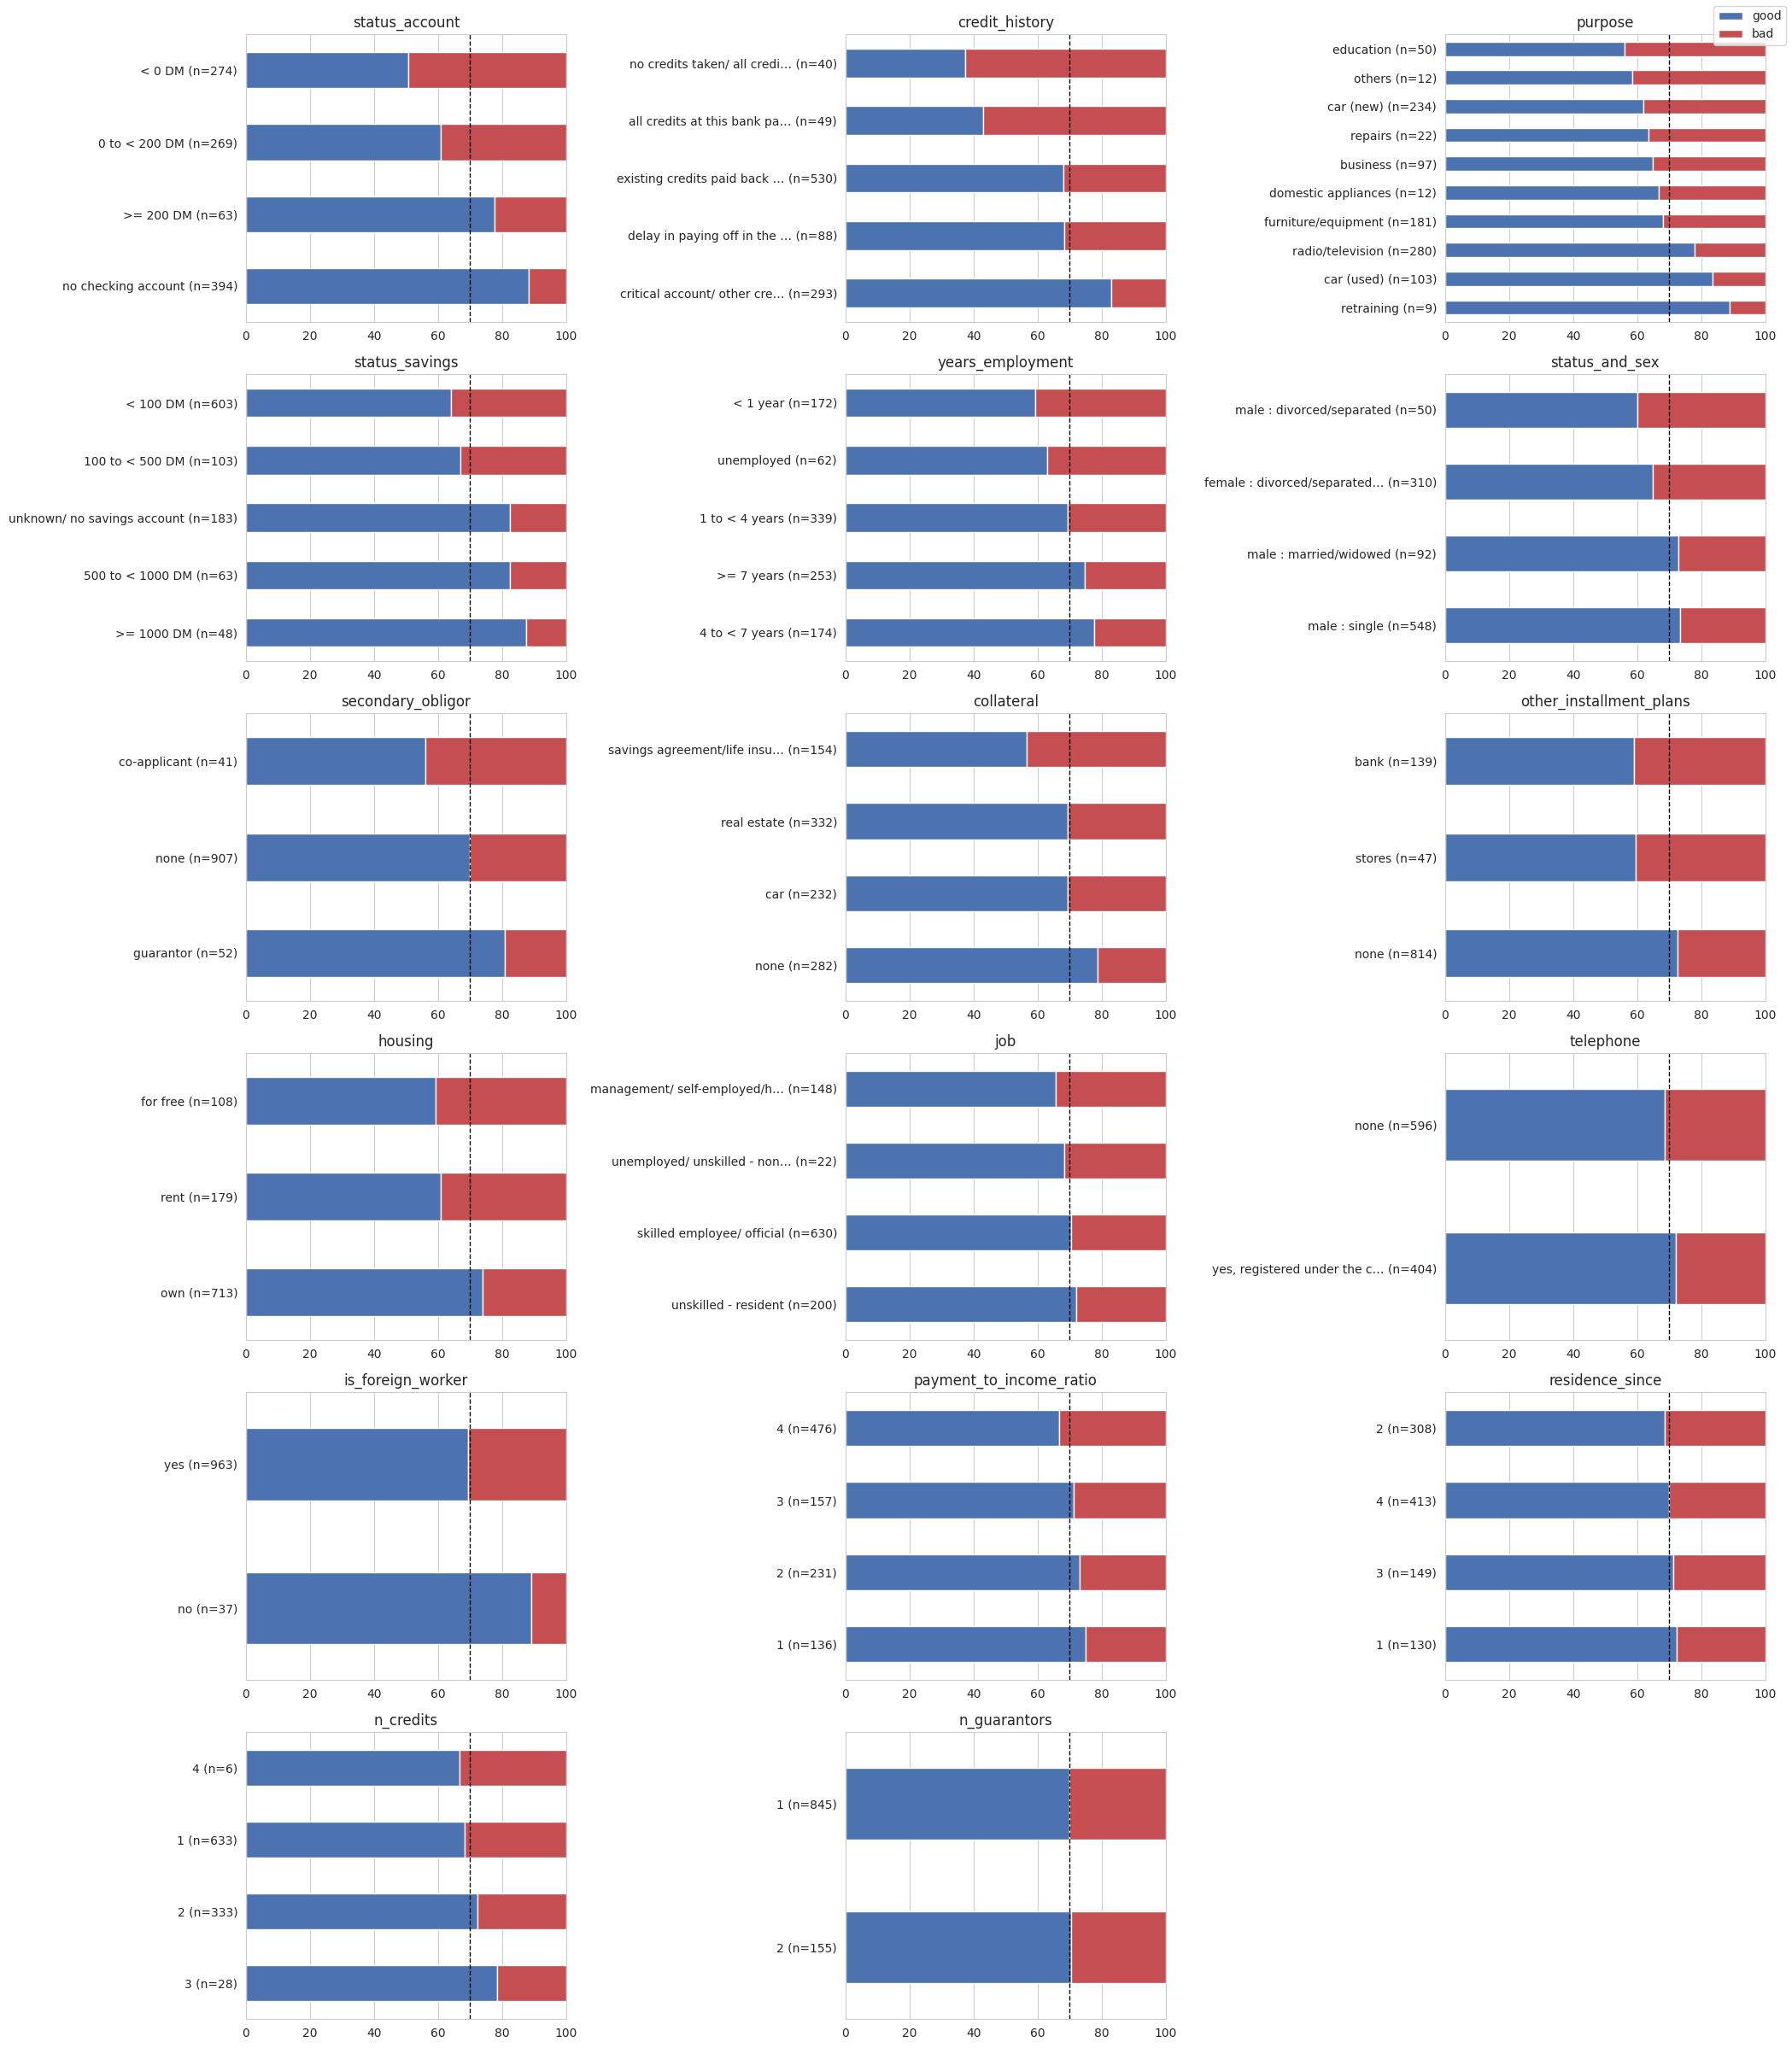

=== 5. % bad por faixa (contínuas) ===


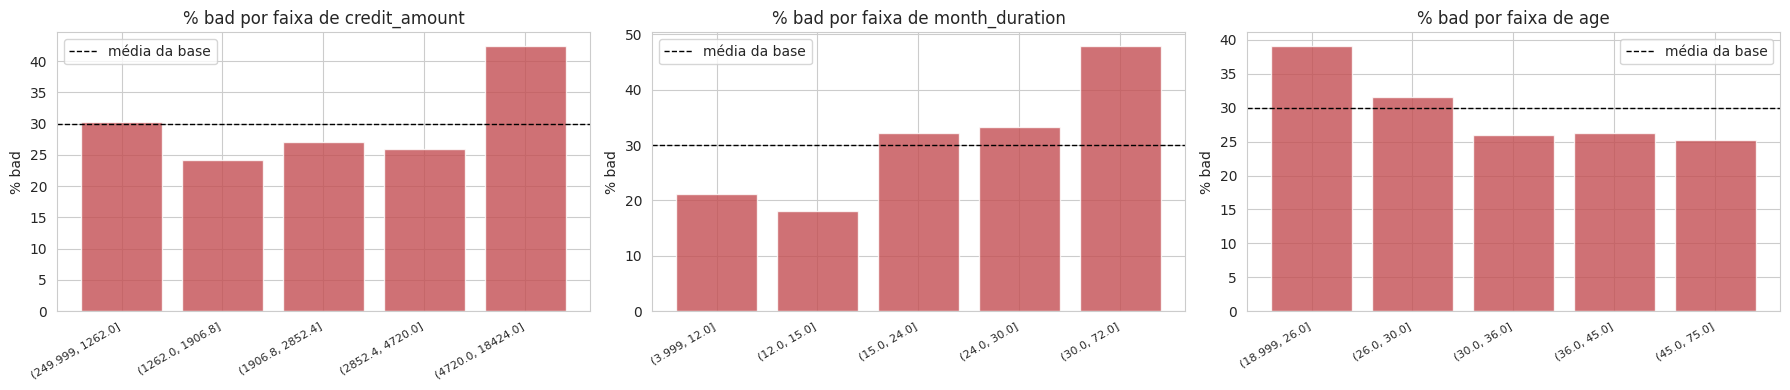

=== 6. Correlação de Pearson ===


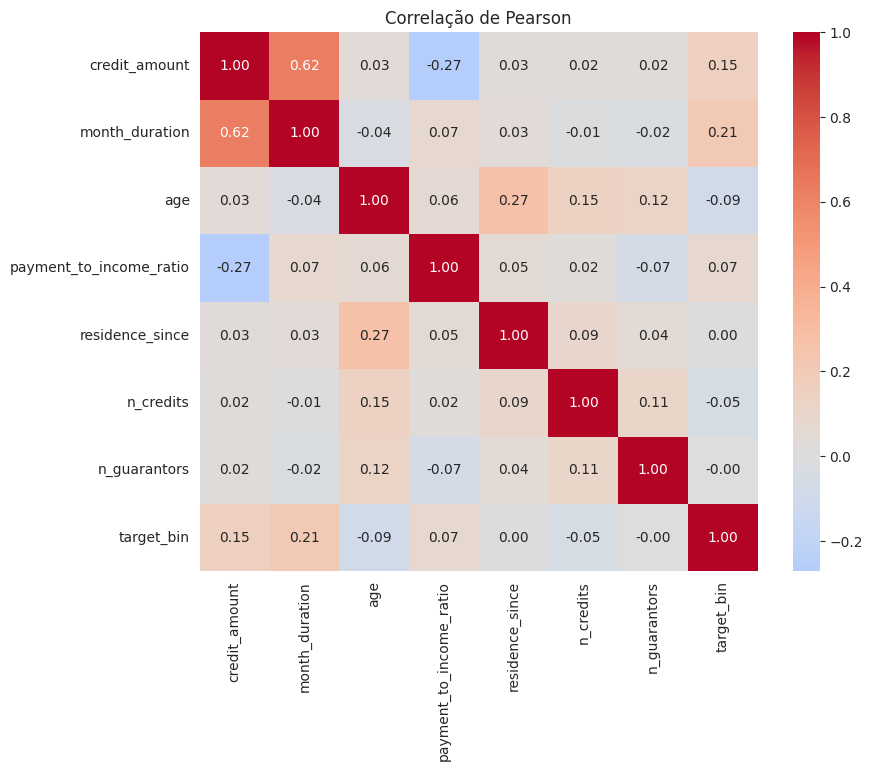

=== 7. Outliers (IQR) ===


,variavel,lim_inf,lim_sup,qtd_outliers,pct_outliers,pct_bad_outliers,pct_bad_base
0,credit_amount,-2544.6,7882.4,72,7.2,54.2,30.0
1,month_duration,-6.0,42.0,70,7.0,57.1,30.0
2,age,4.5,64.5,23,2.3,26.1,30.0


In [26]:
cont_cols = ['credit_amount', 'month_duration', 'age']
disc_cols = ['payment_to_income_ratio', 'residence_since', 'n_credits', 'n_guarantors']
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'target']

eda_visual(df, cont_cols, disc_cols, cat_cols)

### Histogramas e boxplots (numéricas contínuas)

- `credit_amount`: distribuição assimétrica à direita. A média (~ 3.271 DM) fica acima da mediana (~2.320 DM), e a maior concentração está entre 1.000 e 3.000 DM. O boxplot mostra muitos outliers acima de ~7.900 DM, com cauda até 18.424 DM.
- `month_duration`: distribuição multimodal, com picos em 12 e 24 meses e picos menores em 36, 48 e 60. Isso indica prazos padronizados em múltiplos de 12, e não uma variável realmente contínua. A assimetria é moderada (média 20,9 e mediana 18). No boxplot, os outliers começam acima de 42 meses (45, 48, 54, 60 e 72).
- `age`: leve assimetria à direita, com maior concentração entre 23 e 35 anos (mediana 33, média 35,5). Os outliers aparecem acima de ~64 anos e são poucos.

### Barras das variáveis categóricas e discretas (univariada)

- Variáveis com uma categoria dominante: `is_foreign_worker` (96,3% `yes`), `secondary_obligor` (90,7% `none`), `other_installment_plans` (81,4% `none`), `n_guarantors` (84,5% com 1 avalista) e `housing` (71,3% `own`).
- Categorias raras (menos de 3% da base): em `purpose`, `retraining` (0,9%), `others` e `domestic appliances` (1,2% cada) e `repairs` (2,2%); em `job`, `unemployed/ unskilled - non-resident` (2,2%); em `n_credits`, as categorias 3 (2,8%) e 4 (0,6%). Essas categorias terão taxas de bad instáveis e serão agrupadas.
- Variáveis mais equilibradas: `status_account`, `credit_history` (53% em uma categoria), `years_employment` e `collateral`.
- `payment_to_income_ratio` e `residence_since` concentram quase metade da base ou mais na faixa 4 (47,6% e 41,3%).

### KDE por target (numéricas contínuas)

- `month_duration`: é o gráfico que mais separa as classes. Os bons pagadores têm pico forte em ~12 meses, enquanto os maus têm curva mais achatada e deslocada para a direita, com mais massa entre 30 e 50 meses.
- `credit_amount`: os maus têm cauda mais pesada acima de ~5.000 DM, e os bons se concentram em valores baixos (pico em ~1.500 DM). A separação é moderada.
- `age`: a curva dos maus se concentra entre os mais jovens (cerca de 22 a 30 anos), e a dos bons é deslocada para a direita. A separação é fraca a moderada e restrita à faixa jovem.
- O KDE suaviza a distribuição, então a multimodalidade de `month_duration` é visível apenas no histograma.

### Barras 100% empilhadas por target

As barras estão ordenadas por % bad, e a linha tracejada marca a proporção de bons da base (70%).

- Maior poder de separação: `status_account`, `credit_history`, `purpose` e `status_savings`, onde a proporção de bad varia bastante entre as categorias.
- Em `status_account`, `status_savings` e `years_employment`, o % bad varia de forma ordenada entre as categorias, o que favorece a monotonicidade do WoE.
- `payment_to_income_ratio` mostra uma progressão suave e coerente (o bad aumenta com a faixa), mas com baixa amplitude.
- Sem separação visível: `n_guarantors`, `residence_since`, `telephone` e `job`, com barras quase idênticas e próximas da linha de 70%.
- Barras que se afastam muito da linha mas têm `n` pequeno, como `is_foreign_worker = no` (n=37), `retraining` (n=9), `others` (n=12) e `domestic appliances` (n=12), refletem ruído amostral e não devem ser interpretadas isoladamente.
- Os padrões contraintuitivos de `credit_history`, `status_account` e `collateral` aparecem de forma clara nesses gráficos.

### Taxa de bad por faixa (numéricas contínuas)

- `credit_amount`: a taxa é relativamente estável nas quatro primeiras faixas (24% a 30%) e salta para 42,5% na última (acima de ~4.720 DM). A relação é não linear, e o binning pode agrupar as quatro primeiras faixas e separar a mais alta.
- `month_duration`: a taxa cresce com o prazo, de ~21% (até 12 meses) a 48% (acima de 30 meses), com leve queda na faixa de 12 a 15 meses (18,1%). O binning deve corrigir essa não monotonicidade.
- `age`: a taxa cai de 39,2% (até 26 anos) para ~26% a partir dos 30, e estabiliza depois. Duas ou três faixas devem bastar.

### Correlação de Pearson

- A única correlação elevada entre as numéricas é `credit_amount` x `month_duration` (0,62), a monitorar na regressão logística por risco de multicolinearidade.
- Correlações moderadas: `credit_amount` x `payment_to_income_ratio` (-0,27) e `age` x `residence_since` (0,27).
- Em relação ao target, as maiores correlações lineares são `month_duration` (0,21) e `credit_amount` (0,15). `age` (-0,09) e `payment_to_income_ratio` (0,07) são fracas, e `n_guarantors` (-0,00) e `residence_since` (0,00) são nulas.
- O Pearson mede apenas relação linear. `credit_amount` tem correlação baixa com o target, mas apresenta efeito não linear relevante na faixa mais alta, então seu poder preditivo é subestimado por essa métrica.

### Outliers (critério do IQR)

| Variável | Limite superior | Outliers | % da base | % bad nos outliers | % bad da base |
|---|---|---|---|---|---|
| `credit_amount` | 7.882 DM | 72 | 7,2% | 54,2% | 30% |
| `month_duration` | 42 meses | 70 | 7,0% | 57,1% | 30% |
| `age` | 64,5 anos | 23 | 2,3% | 26,1% | 30% |

- Os outliers de valor e prazo têm inadimplência quase o dobro da base. Não são erro de dado, e sim o segmento de maior risco, por isso foram mantidos. O efeito da cauda será tratado por binning e, na regressão logística, avaliando transformação logarítmica.
- Em `age`, a taxa de bad dos outliers (26,1%) é próxima à da base, mas com apenas 23 casos (cerca de 6 inadimplentes), então a leitura é pouco confiável.

#3 - Data Preparation

Objetivo: preparar os dados para construir e validar a política de crédito (#4) sem viés. A regra mais importante aqui: a política vai ser **criada** em uma parte dos dados e **avaliada** em outra parte que ela nunca viu — senão os números de desempenho ficam inflados, porque a regra foi desenhada em cima justamente dos padrões que está tentando prever.

In [ ]:
# Cria uma versao binaria do target para facilitar calculos (1 = mau pagador, 0 = bom pagador)
df['target_bin'] = (df['target'] == 'bad').astype(int)

df[['target', 'target_bin']].head()

,target,target_bin
0,good,0
1,bad,1
2,good,0
3,good,0
4,bad,1


Versão numérica do target: útil para médias, somas e, mais adiante, para o modelo de regressão logística.

In [ ]:
# Split treino/teste estratificado - garante a mesma proporcao de maus pagadores nos dois grupos
df_treino, df_teste = train_test_split(
    df,
    test_size=0.3,
    stratify=df['target'],
    random_state=42
)

print(f'Treino: {df_treino.shape[0]} clientes')
print(f'Teste: {df_teste.shape[0]} clientes')

Treino: 700 clientes
Teste: 300 clientes


In [ ]:
# Confere se a proporcao de maus pagadores ficou igual nos dois grupos
print('Treino:')
print(df_treino['target'].value_counts(normalize=True).round(3))
print()
print('Teste:')
print(df_teste['target'].value_counts(normalize=True).round(3))

Treino:
target
good    0.7
bad     0.3
Name: proportion, dtype: float64

Teste:
target
good    0.7
bad     0.3
Name: proportion, dtype: float64


Split feito com `random_state=42` fixo (reprodutibilidade) e `stratify` para manter ~30% de maus pagadores em ambos os grupos. **A partir daqui, toda regra da política é construída olhando só `df_treino`.** `df_teste` fica guardado e só é usado em #5 - Evaluation, para medir o desempenho real da política em dados que ela nunca viu.

#4 - Modeling

Objetivo: construir um scorecard baseado em regras — a forma como um analista de crédito tradicional pontua um cliente sem usar machine learning. Cada variável relevante vira faixas, cada faixa recebe pontos: quanto menor a taxa de inadimplência da faixa, mais pontos. A soma decide se o cliente é Baixo, Médio ou Alto Risco.

Importante: todas as taxas usadas para definir os pontos abaixo vêm apenas de `df_treino` — o `df_teste` continua intocado até #5.

In [ ]:
# Recalcula as taxas de default por categoria, mas agora so no treino
# (no #2 usamos a base inteira; aqui refazemos so com df_treino, que e a base correta para construir a regra)
for col in ['status_account', 'credit_history', 'status_savings']:
    print(f'--- {col} ---')
    print(df_treino.groupby(col)['target'].apply(lambda x: (x == 'bad').mean()).sort_values(ascending=False).round(3))
    print()

--- status_account ---
status_account
< 0 DM                 0.488
0 to < 200 DM          0.385
>= 200 DM              0.217
no checking account    0.120
Name: target, dtype: float64

--- credit_history ---
credit_history
no credits taken/ all credits paid back duly                   0.586
all credits at this bank paid back duly                        0.571
existing credits paid back duly till now                       0.336
delay in paying off in the past                                0.316
critical account/ other credits existing (not at this bank)    0.159
Name: target, dtype: float64

--- status_savings ---
status_savings
< 100 DM                       0.357
100 to < 500 DM                0.321
unknown/ no savings account    0.192
500 to < 1000 DM               0.139
>= 1000 DM                     0.091
Name: target, dtype: float64



Confirma se os padrões achados em #2 (com a base inteira) se mantêm em `df_treino` (70% da base). Se os números baterem perto, os achados são estáveis e viram regra com segurança.

In [ ]:
# Sistema de pontos: quanto menor a taxa de default da faixa, mais pontos
# Escala simples de 0 a 3 pontos por variavel, calibrada nas taxas de df_treino

pontos_status_account = {
    '< 0 DM': 0,
    '0 to < 200 DM': 1,
    '>= 200 DM': 2,
    'no checking account': 3
}

pontos_credit_history = {
    'no credits taken/ all credits paid back duly': 0,
    'all credits at this bank paid back duly': 0,
    'existing credits paid back duly till now': 1,
    'delay in paying off in the past': 1,
    'critical account/ other credits existing (not at this bank)': 3
}

pontos_status_savings = {
    '< 100 DM': 0,
    '100 to < 500 DM': 1,
    'unknown/ no savings account': 2,
    '500 to < 1000 DM': 2,
    '>= 1000 DM': 3
}

def calcular_score(dataframe):
    score = (
        dataframe['status_account'].map(pontos_status_account) +
        dataframe['credit_history'].map(pontos_credit_history) +
        dataframe['status_savings'].map(pontos_status_savings)
    )
    return score

df_treino = df_treino.copy()
df_treino['score'] = calcular_score(df_treino)

df_treino[['status_account', 'credit_history', 'status_savings', 'score', 'target']].head(10)

,status_account,credit_history,status_savings,score,target
328,>= 200 DM,existing credits paid back duly till now,< 100 DM,3,good
891,no checking account,critical account/ other credits existing (not ...,< 100 DM,6,good
255,0 to < 200 DM,delay in paying off in the past,unknown/ no savings account,4,good
243,no checking account,critical account/ other credits existing (not ...,< 100 DM,6,good
492,no checking account,critical account/ other credits existing (not ...,100 to < 500 DM,7,good
597,0 to < 200 DM,no credits taken/ all credits paid back duly,< 100 DM,1,bad
7,0 to < 200 DM,existing credits paid back duly till now,< 100 DM,2,good
951,< 0 DM,delay in paying off in the past,< 100 DM,1,bad
224,no checking account,existing credits paid back duly till now,< 100 DM,4,good
317,0 to < 200 DM,existing credits paid back duly till now,unknown/ no savings account,4,good


Pontuação de 0 a 3 por variável (0 = pior faixa, 3 = melhor faixa), somando 0 a 9 no total. Os pesos seguem exatamente o ranking de taxa de default visto na célula 32 — nenhum valor foi "chutado", cada ponto tem uma taxa real por trás.

In [ ]:
# Taxa de default por score total - o scorecard so e util se essa taxa cair conforme o score sobe
df_treino.groupby('score')['target_bin'].agg(['mean', 'count']).round(3)

,mean,count
score,,
0,0.800,15
1,0.566,113
2,0.465,86
3,0.362,116
4,0.210,138
5,0.156,45
6,0.088,114
7,0.154,26
8,0.056,36


O score discrimina bem no geral: a taxa de default cai de 80% (score 0) para 0% (score 9), queda consistente na maior parte da escala. Uma quebra pontual aparece no score 7 (15,4%), acima do score 6 (8,8%) — provavelmente ruído, já que a faixa tem só 26 clientes.

As faixas extremas também têm pouca gente (score 0: 15 clientes; score 9: 11 clientes), então as taxas de 80% e 0% ali são pouco confiáveis isoladamente. É por isso que o próximo passo agrupa o score bruto em 3 faixas de risco em vez de usar os 10 valores individuais — o agrupamento absorve esse ruído de amostra pequena e entrega grupos com volume suficiente para sustentar uma decisão de política.

In [ ]:
# Agrupa o score bruto (0-9) em 3 faixas de risco, absorvendo a instabilidade de scores com poucos clientes
def faixa_risco(score):
    if score <= 2:
        return 'Alto Risco'
    elif score <= 5:
        return 'Medio Risco'
    else:
        return 'Baixo Risco'

df_treino['faixa_risco'] = df_treino['score'].apply(faixa_risco)

df_treino.groupby('faixa_risco')['target_bin'].agg(['mean', 'count']).round(3)

,mean,count
faixa_risco,,
Alto Risco,0.542,214
Baixo Risco,0.086,187
Medio Risco,0.261,299


As 3 faixas de risco ficaram bem separadas, com volume relevante em todas:

- **Alto Risco:** 54,2% de default, 214 clientes (30,6% do treino)
- **Medio Risco:** 26,1% de default, 299 clientes (42,7%) — proximo da media geral de 30%
- **Baixo Risco:** 8,6% de default, 187 clientes (26,7%)

A distancia entre Alto e Baixo Risco e grande (54,2% vs 8,6%, mais de 6x), o que mostra que o scorecard discrimina bem, nao e so ruido. E esse tipo de resultado - faixas com taxas bem distantes e volume equilibrado entre elas - que sustenta a credibilidade de uma politica baseada em regras.

In [ ]:
# Politica de credito baseada nas faixas de risco
def decisao_politica(faixa):
    if faixa == 'Alto Risco':
        return 'Reprovado'
    elif faixa == 'Medio Risco':
        return 'Aprovado com restricao'
    else:
        return 'Aprovado'

df_treino['decisao_politica'] = df_treino['faixa_risco'].apply(decisao_politica)

df_treino['decisao_politica'].value_counts()

,count
decisao_politica,
Aprovado com restricao,299
Reprovado,214
Aprovado,187


Regra de decisão direta a partir da faixa de risco: Alto Risco é reprovado, Médio Risco aprovado com restrição (ex: limite reduzido ou garantia — decisão operacional que fica fora do escopo deste notebook), Baixo Risco aprovado normalmente.

In [ ]:
# Taxa de mau pagador entre os aprovados vs cenario de aprovar todo mundo
aprovados = df_treino[df_treino['decisao_politica'] != 'Reprovado']

tx_maus_aprovados = aprovados['target_bin'].mean()
tx_aprovacao = len(aprovados) / len(df_treino)

print(f'Taxa de aprovacao: {tx_aprovacao:.1%}')
print(f'Taxa de maus pagadores entre aprovados: {tx_maus_aprovados:.1%}')
print(f'Taxa de maus pagadores se aprovasse todos (baseline): {df_treino["target_bin"].mean():.1%}')

Taxa de aprovacao: 69.4%
Taxa de maus pagadores entre aprovados: 19.3%
Taxa de maus pagadores se aprovasse todos (baseline): 30.0%


Resultado da politica no treino:

- **Taxa de aprovacao:** 69,4% (dos 700 clientes, 486 foram aprovados ou aprovados com restricao)
- **Taxa de maus pagadores entre aprovados:** 19,3%, contra 30% do baseline
- **Reducao de inadimplencia:** de 30% para 19,3% entre os aprovados - uma queda de 10,7 pontos percentuais, ou cerca de 36% de reducao relativa

Isso significa que a politica reduz a inadimplencia da carteira aprovada em mais de um terco, sacrificando 30,6% do volume (os reprovados). O trade-off precisa ser lido em conjunto com o proximo passo: quantos desses reprovados eram, na verdade, bons pagadores - isso mede o custo de oportunidade da politica.

In [ ]:
# Dos clientes reprovados, quantos eram na verdade bons pagadores? (receita perdida)
reprovados = df_treino[df_treino['decisao_politica'] == 'Reprovado']

tx_bons_reprovados = (reprovados['target_bin'] == 0).mean()

print(f'Clientes reprovados: {len(reprovados)}')
print(f'Taxa de bons pagadores entre os reprovados: {tx_bons_reprovados:.1%}')

Clientes reprovados: 214
Taxa de bons pagadores entre os reprovados: 45.8%


Dos 214 clientes reprovados (Alto Risco), **45,8% eram bons pagadores** - quase metade. Esse e o custo real da politica: para reduzir a inadimplencia de 30% para 19,3% entre aprovados, a politica sacrifica quase 100 bons clientes (214 x 45,8% ≈ 98) que pagariam normalmente.

Essa taxa e alta o suficiente para questionar o corte: uma politica ideal minimiza esse numero sem perder poder de reducao de risco. Vale registrar como limitacao no notebook - "a politica atual prioriza reducao de inadimplencia mesmo as custas de um volume relevante de bons pagadores rejeitados, e um ajuste de corte pode reduzir esse custo".

In [ ]:
# Resumo visual do trade-off: taxa de default por faixa de risco e decisao aplicada
resumo = df_treino.groupby('faixa_risco').agg(
    n_clientes=('target_bin', 'count'),
    tx_default=('target_bin', 'mean')
).round(3)
resumo['decisao'] = ['Reprovado', 'Aprovado', 'Aprovado com restricao']

resumo

,n_clientes,tx_default,decisao
faixa_risco,,,
Alto Risco,214,0.542,Reprovado
Baixo Risco,187,0.086,Aprovado
Medio Risco,299,0.261,Aprovado com restricao


### Custo esperado da política (matriz de custo)

A literatura do German Credit define uma matriz de custo assimétrica: aprovar um mau pagador custa **5x mais** do que reprovar um bom pagador (custo de reprovar um bom = 1, custo de aprovar um mau = 5). Isso traduz o trade-off em uma única métrica de negócio, em vez de olhar taxas separadas.

In [ ]:
# Matriz de custo classica do German Credit: aprovar mau = 5, reprovar bom = 1
CUSTO_APROVAR_MAU = 5
CUSTO_REPROVAR_BOM = 1

def custo_politica(dataframe):
    aprovados = dataframe[dataframe['decisao_politica'] != 'Reprovado']
    reprovados = dataframe[dataframe['decisao_politica'] == 'Reprovado']

    n_maus_aprovados = (aprovados['target_bin'] == 1).sum()
    n_bons_reprovados = (reprovados['target_bin'] == 0).sum()

    custo_total = n_maus_aprovados * CUSTO_APROVAR_MAU + n_bons_reprovados * CUSTO_REPROVAR_BOM
    custo_medio = custo_total / len(dataframe)

    return n_maus_aprovados, n_bons_reprovados, custo_total, custo_medio

n_maus_aprovados, n_bons_reprovados, custo_total, custo_medio = custo_politica(df_treino)

n_maus_total = (df_treino['target_bin'] == 1).sum()
custo_aprovar_todos = n_maus_total * CUSTO_APROVAR_MAU
custo_medio_aprovar_todos = custo_aprovar_todos / len(df_treino)

print(f'Maus pagadores aprovados: {n_maus_aprovados}')
print(f'Bons pagadores reprovados: {n_bons_reprovados}')
print(f'Custo total da politica: {custo_total} (medio por cliente: {custo_medio:.3f})')
print(f'Custo se aprovasse todo mundo: {custo_aprovar_todos} (medio por cliente: {custo_medio_aprovar_todos:.3f})')
print(f'Reducao de custo da politica vs aprovar todos: {(1 - custo_total/custo_aprovar_todos):.1%}')

Maus pagadores aprovados: 94
Bons pagadores reprovados: 98
Custo total da politica: 568 (medio por cliente: 0.811)
Custo se aprovasse todo mundo: 1050 (medio por cliente: 1.500)
Reducao de custo da politica vs aprovar todos: 45.9%


Com a matriz de custo 5:1, a política é avaliada pelo **custo esperado da carteira**, não só pela taxa de default. Se a redução de custo (célula acima) for bem menor do que a redução de taxa de default sugeria, é sinal de que a política está pagando um preço alto demais em bons pagadores rejeitados para o ganho real que entrega — essa conta, e não a taxa de default isolada, é o que deveria decidir se o corte atual entre Médio e Alto Risco é o certo.

### Quantificando a faixa "Aprovado com restrição"

A política atual deixa a faixa de Médio Risco (26,1% de default) com uma decisão qualitativa ("aprovado com restrição"), sem quantificar o que muda na prática. Uma regra operacional mínima, coerente com o guia do projeto: reduzir o limite concedido para 70% do valor solicitado nessa faixa. Isso não muda quem é aprovado, mas reduz a exposição (EAD) por cliente, o que reduz a perda esperada mesmo sem reduzir a taxa de default.

In [ ]:
# Quantifica o efeito de reduzir o limite para 70% do valor solicitado na faixa Medio Risco
PERCENTUAL_LIMITE_RESTRICAO = 0.70

medio_risco = df_treino[df_treino['faixa_risco'] == 'Medio Risco']
exposicao_original = medio_risco['credit_amount'].sum()
exposicao_com_restricao = exposicao_original * PERCENTUAL_LIMITE_RESTRICAO

print(f'Exposicao original (Medio Risco): {exposicao_original:,.0f} DM')
print(f'Exposicao com limite reduzido a 70%: {exposicao_com_restricao:,.0f} DM')
print(f'Reducao de exposicao: {exposicao_original - exposicao_com_restricao:,.0f} DM ({1 - PERCENTUAL_LIMITE_RESTRICAO:.0%})')

Exposicao original (Medio Risco): 958,032 DM
Exposicao com limite reduzido a 70%: 670,622 DM
Reducao de exposicao: 287,410 DM (30%)


Reduzir o limite em 30% para a faixa de Médio Risco reduz a exposição total dessa faixa na mesma proporção, sem alterar quem é aprovado ou a taxa de default observada — é uma alavanca independente do scorecard, e junto com o corte de score, compõe a política completa.

#5 - Evaluation

Objetivo: validar se a politica desenhada em `df_treino` se sustenta em `df_teste` (300 clientes nunca vistos). Se os numeros ficarem parecidos, a politica generaliza bem. Se cairem muito, a politica estava sobreajustada ao treino.

In [ ]:
# Aplica exatamente a mesma logica (pontos, faixas, decisao) no df_teste
df_teste = df_teste.copy()
df_teste['score'] = calcular_score(df_teste)
df_teste['faixa_risco'] = df_teste['score'].apply(faixa_risco)
df_teste['decisao_politica'] = df_teste['faixa_risco'].apply(decisao_politica)

resumo_teste = df_teste.groupby('faixa_risco').agg(
    n_clientes=('target_bin', 'count'),
    tx_default=('target_bin', 'mean')
).round(3)

resumo_teste

,n_clientes,tx_default
faixa_risco,,
Alto Risco,92,0.554
Baixo Risco,88,0.114
Medio Risco,120,0.242


In [ ]:
# Mesmas 3 metricas calculadas no teste
aprovados_teste = df_teste[df_teste['decisao_politica'] != 'Reprovado']
reprovados_teste = df_teste[df_teste['decisao_politica'] == 'Reprovado']

tx_aprovacao_teste = len(aprovados_teste) / len(df_teste)
tx_maus_aprovados_teste = aprovados_teste['target_bin'].mean()
tx_bons_reprovados_teste = (reprovados_teste['target_bin'] == 0).mean()

print(f'Taxa de aprovacao (teste): {tx_aprovacao_teste:.1%}')
print(f'Taxa de maus pagadores entre aprovados (teste): {tx_maus_aprovados_teste:.1%}')
print(f'Taxa de bons pagadores entre reprovados (teste): {tx_bons_reprovados_teste:.1%}')

Taxa de aprovacao (teste): 69.3%
Taxa de maus pagadores entre aprovados (teste): 18.8%
Taxa de bons pagadores entre reprovados (teste): 44.6%


Comparação treino vs teste — a política generalizou muito bem:

| Métrica | Treino | Teste | Diferença |
|---|---|---|---|
| Taxa de aprovação | 69,4% | 69,3% | -0,1 p.p. |
| Maus pagadores entre aprovados | 19,3% | 18,8% | -0,5 p.p. |
| Bons pagadores entre reprovados | 45,8% | 44,6% | -1,2 p.p. |

As diferenças são mínimas (menos de 1,5 ponto percentual em tudo), o que indica que a política **não está sobreajustada** ao treino — os padrões de `status_account`, `credit_history` e `status_savings` são estáveis o suficiente para se repetir em dados novos. Isso é o resultado mais importante do projeto: prova que a política é confiável.

**Resumo final da política v1:**
- Reduz a inadimplência de 30% (baseline) para ~19% entre aprovados — queda de ~37% relativa
- Aprova cerca de 69% da carteira
- Custo: cerca de 45% dos reprovados são, na verdade, bons pagadores — o principal ponto de melhoria para uma v2 (ajuste de corte, ou variáveis adicionais no score)

In [ ]:
# Mesmo calculo de custo, agora no df_teste, para confirmar que a economia de custo tambem generaliza
n_maus_aprovados_teste, n_bons_reprovados_teste, custo_total_teste, custo_medio_teste = custo_politica(df_teste)

n_maus_total_teste = (df_teste['target_bin'] == 1).sum()
custo_aprovar_todos_teste = n_maus_total_teste * CUSTO_APROVAR_MAU
custo_medio_aprovar_todos_teste = custo_aprovar_todos_teste / len(df_teste)

print(f'Custo medio da politica (teste): {custo_medio_teste:.3f}')
print(f'Custo medio se aprovasse todos (teste): {custo_medio_aprovar_todos_teste:.3f}')
print(f'Reducao de custo (teste): {(1 - custo_total_teste/custo_aprovar_todos_teste):.1%}')

Custo medio da politica (teste): 0.787
Custo medio se aprovasse todos (teste): 1.500
Reducao de custo (teste): 47.6%


A redução de custo no teste (47,6%) confirma — e até supera ligeiramente — a redução observada no treino (45,9%). A política não só generaliza bem em taxa de aprovação e taxa de maus pagadores (visto acima), como também generaliza no ganho de custo esperado, que é a métrica que realmente importa para a carteira

#6 - Deployment

Objetivo: traduzir o projeto em uma recomendação de negócio, documentar o que foi feito e deixar claro o próximo passo.

### Benchmark: regressão logística



In [ ]:
# One-hot encoding das variaveis categoricas candidatas (incluindo as que ficaram de fora do scorecard)
from sklearn.metrics import roc_curve

variaveis_candidatas = ['status_account', 'credit_history', 'status_savings', 'purpose', 'housing', 'years_employment']

X_treino = pd.get_dummies(df_treino[variaveis_candidatas], drop_first=True)
y_treino = df_treino['target_bin']

X_teste = pd.get_dummies(df_teste[variaveis_candidatas], drop_first=True)
X_teste = X_teste.reindex(columns=X_treino.columns, fill_value=0)
y_teste = df_teste['target_bin']

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_treino, y_treino)

proba_teste = modelo.predict_proba(X_teste)[:, 1]
auc_modelo = roc_auc_score(y_teste, proba_teste)
gini_modelo = 2 * auc_modelo - 1

fpr, tpr, _ = roc_curve(y_teste, proba_teste)
ks_modelo = (tpr - fpr).max()

print(f'AUC (regressao logistica, teste): {auc_modelo:.3f}')
print(f'Gini (regressao logistica, teste): {gini_modelo:.3f}')
print(f'KS (regressao logistica, teste): {ks_modelo:.3f}')

AUC (regressao logistica, teste): 0.743
Gini (regressao logistica, teste): 0.485
KS (regressao logistica, teste): 0.408


In [ ]:
# Mesmas metricas para o scorecard de regras, para comparacao direta
score_teste = df_teste['score']  # score bruto 0-9, quanto maior, menor o risco

# Inverte o sinal: para roc_auc_score, valor mais alto deve indicar MAIOR risco (classe 1)
auc_scorecard = roc_auc_score(y_teste, -score_teste)
gini_scorecard = 2 * auc_scorecard - 1

fpr_sc, tpr_sc, _ = roc_curve(y_teste, -score_teste)
ks_scorecard = (tpr_sc - fpr_sc).max()

print(f'AUC (scorecard de regras, teste): {auc_scorecard:.3f}')
print(f'Gini (scorecard de regras, teste): {gini_scorecard:.3f}')
print(f'KS (scorecard de regras, teste): {ks_scorecard:.3f}')
print()
print(f'Diferenca de Gini (modelo - scorecard): {gini_modelo - gini_scorecard:+.3f}')

AUC (scorecard de regras, teste): 0.741
Gini (scorecard de regras, teste): 0.482
KS (scorecard de regras, teste): 0.371

Diferenca de Gini (modelo - scorecard): +0.004


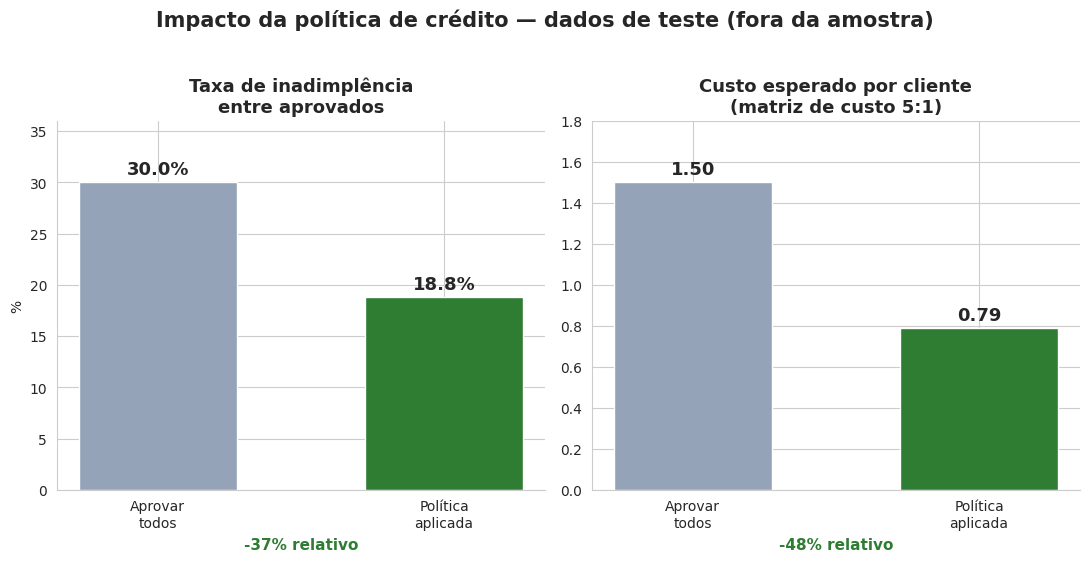

In [ ]:
# Impacto da política de crédito: aprovar todos vs política aplicada (dados de teste)
cenarios = ['Aprovar\ntodos', 'Política\naplicada']
tx_default = [30.0, 18.8]
custo = [1.50, 0.79]
cores = ['#94A3B8', '#2E7D32']

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

bars1 = axes[0].bar(cenarios, tx_default, color=cores, width=0.55)
axes[0].set_title('Taxa de inadimplência\nentre aprovados', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 36)
axes[0].set_ylabel('%')
for bar, val in zip(bars1, tx_default):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].text(0.5, -0.16, '-37% relativo', transform=axes[0].transAxes, ha='center', fontsize=11, color='#2E7D32', fontweight='bold')

bars2 = axes[1].bar(cenarios, custo, color=cores, width=0.55)
axes[1].set_title('Custo esperado por cliente\n(matriz de custo 5:1)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.8)
for bar, val in zip(bars2, custo):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.04, f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')
axes[1].text(0.5, -0.16, '-48% relativo', transform=axes[1].transAxes, ha='center', fontsize=11, color='#2E7D32', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Impacto da política de crédito — dados de teste (fora da amostra)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Como interpretar:** se a diferença de Gini for pequena (poucos centésimos), o scorecard de 3 variáveis já captura a maior parte do sinal disponível nesta base pequena, e a simplicidade/explicabilidade do scorecard pode compensar a complexidade extra do modelo. Se a diferença for grande, é sinal de que purpose, housing e years_employment carregam informação relevante que o scorecard v1 está deixando de usar.



**Limitação:** variáveis sensíveis não usadas, mas presentes na base
A base contém status_and_sex (estado civil cruzado com gênero) e is_foreign_worker (trabalhador estrangeiro). Nenhuma das duas entrou no scorecard ou no benchmark acima — mas isso não elimina o risco de viés indireto: variáveis como housing, job ou purpose podem correlacionar com essas características sensíveis e reproduzir discriminação de forma indireta, mesmo sem usá-las diretamente. Um projeto de crédito real precisaria de uma análise de fairness (ex: taxa de aprovação e de erro por subgrupo) antes de qualquer uso em produção. Este notebook não faz essa análise — fica registrado como limitação explícita, não como algo resolvido.




##**Resumo executivo**

**Problema:** a carteira de crédito tinha 30% de inadimplência geral. O objetivo era construir uma política que reduzisse esse risco sem sacrificar volume excessivo de bons pagadores, avaliando o resultado em custo esperado (não só em taxa).

**O que foi feito:** análise exploratória de 1.000 clientes identificou três variáveis com forte poder de discriminação — status da conta corrente, histórico de crédito e conta poupança. A partir delas, foi construído um scorecard baseado em regras (0 a 9 pontos), agrupado em três faixas de risco, com uma política de aprovação por faixa. A política foi criada em 70% da base (treino) e validada nos 30% restantes (teste), nunca vistos durante a construção. Como benchmark, uma regressão logística com todas as variáveis candidatas (incluindo purpose, housing e years_employment, que o scorecard não usa) foi comparada em KS e Gini.

**Resultado:**

Reduz a inadimplência entre aprovados de 30% para ~19% (queda de ~37% relativa)
Aprova ~69% da carteira

Com a matriz de custo (aprovar mau = 5x reprovar bom), a política reduz o custo médio por cliente de 1,500 (aprovar todos) para 0,811 no treino (queda de 45,9%) e de 1,500 para 0,787 no teste (queda de 47,6%) — a redução de custo se confirma fora da amostra de treino, e é até um pouco maior no teste

**Validado em dados fora da amostra:** diferença menor que 1,5 p.p. entre treino e teste em todas as métricas de taxa — a política generaliza bem, não está sobreajustada

Benchmark de regressão logística indica que o scorecard de 3 variáveis já captura quase todo o sinal disponível: Gini de 0,485 (regressão) vs. 0,482 (scorecard), diferença de apenas +0,004, e AUC praticamente igual (0,743 vs. 0,741). A maior diferença aparece no KS (0,408 vs. 0,371), mas ainda é pequena — não há espaço relevante para um modelo mais completo nesta base

**Recomendação:** adotar a política v1 como baseline, com duas ressalvas: (1) ~45% dos reprovados são bons pagadores — reduzir o limite para 70% do valor solicitado na faixa de Médio Risco (calculado acima) é uma alavanca de redução de exposição independente do corte de score; (2) o scorecard usa só 3 variáveis — o benchmark mostra que a regressão logística com variáveis adicionais (purpose, housing, years_employment) ganha muito pouco, então expandir o modelo não é prioridade nesta base — o ganho maior está em ajustar o corte de score, não em adicionar variáveis.

**Limitações:**

Scorecard usa apenas 3 variáveis; o benchmark de regressão logística (Gini +0,004, KS +0,037) mostra que o espaço de melhoria com mais variáveis é pequeno nesta base

Pesos por faixa foram definidos por ranking de taxa de default, não por WOE/IV formal ou otimização — próximo passo natural

Nenhuma análise de fairness foi feita; variáveis sensíveis (status_and_sex, is_foreign_worker) não entraram no modelo, mas viés indireto via variáveis correlacionadas não foi descartado

Dataset sintético/histórico (German Credit, 1994), sem dimensão temporal — não é possível avaliar estabilidade da política ao longo do tempo
Amostra pequena (1.000 clientes): categorias como "retraining" (9 clientes) e scores extremos (0 e 9, <16 clientes cada) têm taxas pouco confiáveis isoladamente